In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/superheated_vapor.csv')
df.head()

,Pressure,Property,Liq_Sat,Vap_Sat,75,100,125,150,175,200,...,425,450,475,500,525,550,575,600,625,650
0,1.0,V,1.000,129200.0000,160640.0000,172180.0000,183720.0000,195270.0000,206810.0000,218350.0000,...,NaN,333730.00,NaN,356810.0000,NaN,379880.0000,NaN,402960.0000,NaN,426040.0000
1,1.0,U,29.334,2385.2000,2480.8000,2516.4000,2552.3000,2588.5000,2624.9000,2661.7000,...,NaN,3049.90,NaN,3132.4000,NaN,3216.7000,NaN,3302.6000,NaN,3390.3000
2,1.0,H,29.335,2514.4000,2641.5000,2688.6000,2736.0000,2783.7000,2831.7000,2880.1000,...,NaN,3383.60,NaN,3489.2000,NaN,3596.5000,NaN,3705.6000,NaN,3816.4000
3,1.0,S,0.106,8.9767,9.3828,9.5136,9.6365,9.7527,9.8629,9.9679,...,NaN,10.82,NaN,10.9612,NaN,11.0957,NaN,11.2243,NaN,11.3476
4,10.0,V,1.010,14670.0000,16030.0000,17190.0000,18350.0000,19510.0000,20660.0000,21820.0000,...,NaN,33370.00,NaN,35670.0000,NaN,37980.0000,NaN,40290.0000,NaN,42600.0000


In [3]:
# Choosing to continue with V
V = df.loc[df['Property'] == 'V']
V.shape

(136, 37)

In [4]:
V.head()

,Pressure,Property,Liq_Sat,Vap_Sat,75,100,125,150,175,200,...,425,450,475,500,525,550,575,600,625,650
0,1.0,V,1.000,129200.0,160640.0,172180.0,183720.0,195270.0,206810.0,218350.0,...,NaN,333730.0,NaN,356810.0,NaN,379880.0,NaN,402960.0,NaN,426040.0
4,10.0,V,1.010,14670.0,16030.0,17190.0,18350.0,19510.0,20660.0,21820.0,...,NaN,33370.0,NaN,35670.0,NaN,37980.0,NaN,40290.0,NaN,42600.0
8,20.0,V,1.017,7649.8,8000.0,8584.7,9167.1,9748.0,10320.0,10900.0,...,NaN,16680.0,NaN,17830.0,NaN,18990.0,NaN,20140.0,NaN,21300.0
12,30.0,V,1.022,5229.3,5322.0,5714.4,6104.6,6493.2,6880.8,7267.5,...,NaN,11120.0,NaN,11890.0,NaN,12660.0,NaN,13430.0,NaN,14190.0
16,40.0,V,1.027,3993.4,NaN,4279.2,4573.3,4865.8,5157.2,5447.8,...,NaN,8340.1,NaN,8917.6,NaN,9494.9,NaN,10070.0,NaN,10640.0


In [7]:
# Fitting a linear model with Pressure as the independent variable and Liq_Sat as the dependent variable
Ps = V["Pressure"].to_numpy().reshape(-1, 1)
Vs = V["Liq_Sat"].to_numpy().reshape(-1, 1)

# import polynomial features
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# Import pipeline
from sklearn.pipeline import Pipeline
pf = PolynomialFeatures(degree=4, include_bias=False)
Lr = LinearRegression()
model = Pipeline([("polynomial_features", pf), ("linear_regression", Lr)])

model.fit(Ps, Vs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomial_features', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",4
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


In [8]:
print ("The coefficients are:", model.named_steps['linear_regression'].coef_)      
print ("The intercept is:", model.named_steps['linear_regression'].intercept_)
print ("The R-squared value is:", model.score(Ps, Vs))

The coefficients are: [[ 5.39086776e-20  3.36548772e-16  1.48348501e-12 -1.12705225e-16]]
The intercept is: [1.12604946]
The R-squared value is: 0.8657884836112323


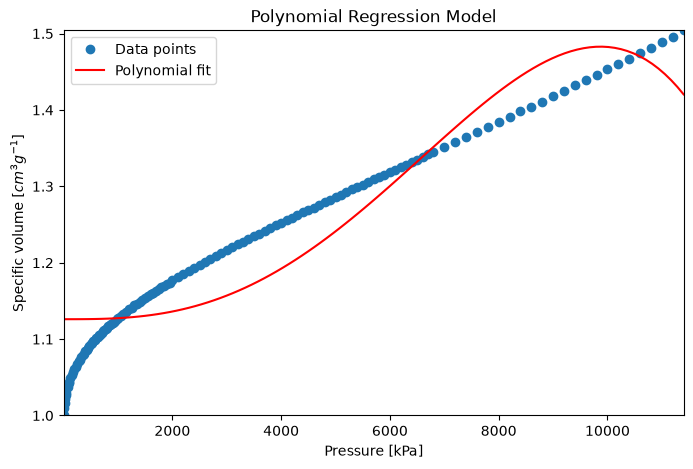

In [10]:
# Plotting the graph
import matplotlib.pyplot as plt

evaluation_points = np.linspace(Ps.min(), Ps.max(), 100).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.plot(Ps, Vs, 'o', label='Data points')
plt.plot(evaluation_points, model.predict(evaluation_points), label='Polynomial fit', color='red')
plt.title('Polynomial Regression Model')
plt.xlabel('Pressure [kPa]')
plt.ylabel('Specific volume [$cm^3 g^{-1}$]')
plt.xlim(Ps.min(), Ps.max())
plt.ylim(Vs.min(), Vs.max())
plt.legend()
plt.show()


In [12]:
# Let's create a function which can take any number of polynomial features

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def polynomial_model(X, y,n):
    pf = PolynomialFeatures(degree=n, include_bias=False)
    Lr = LinearRegression()
    model_poly = Pipeline([("polynomial_features", pf), ("linear_regression", Lr)])
    model_poly.fit(X, y)
    return model_poly

def plot_polynomial_fit(X, y, model_poly):
    evaluation_points = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    plt.figure(figsize=(8, 5))
    plt.plot(X, y, 'o', label='Data points')
    plt.plot(evaluation_points, model_poly.predict(evaluation_points), label='Polynomial fit', color='red')
    plt.title('Polynomial Regression Model')
    plt.xlabel('Pressure [kPa]')
    plt.ylabel('Specific volume [$cm^3 g^{-1}$]')
    plt.xlim(X.min(), X.max())
    plt.ylim(y.min(), y.max())
    plt.legend()
    plt.show()    

Degree: 1
The coefficients are: [[3.92152714e-05]]
The intercept is: [1.0780201]
The R-squared value is: 0.9751457240928116


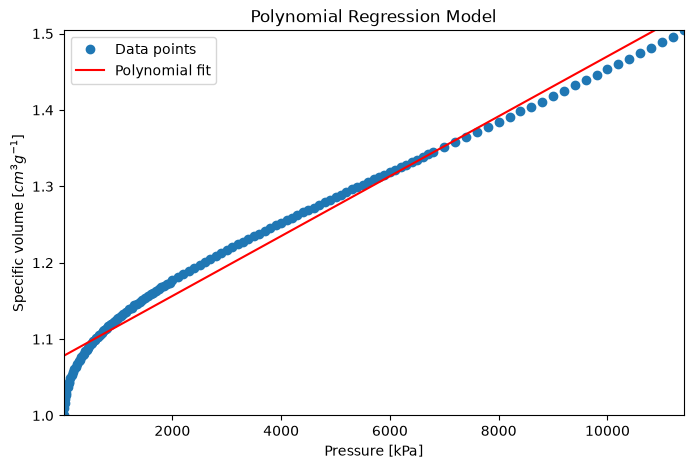

Degree: 2
The coefficients are: [[ 5.32533266e-05 -1.45350089e-09]]
The intercept is: [1.06189229]
The R-squared value is: 0.9870375378361614


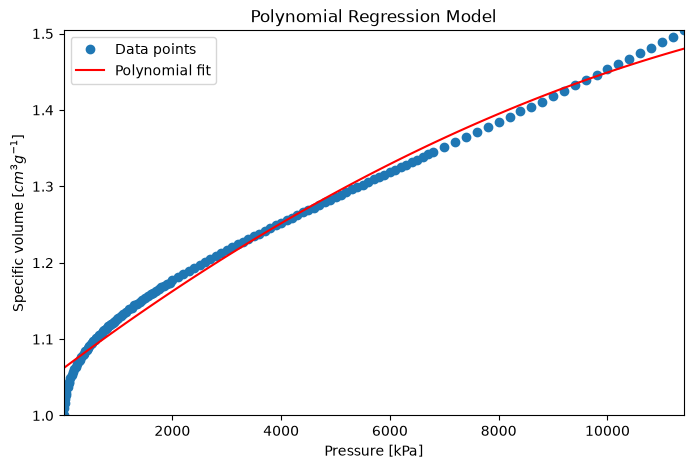

Degree: 3
The coefficients are: [[ 2.30516561e-12  1.00458123e-08 -6.47966791e-13]]
The intercept is: [1.10408795]
The R-squared value is: 0.9350441059135135


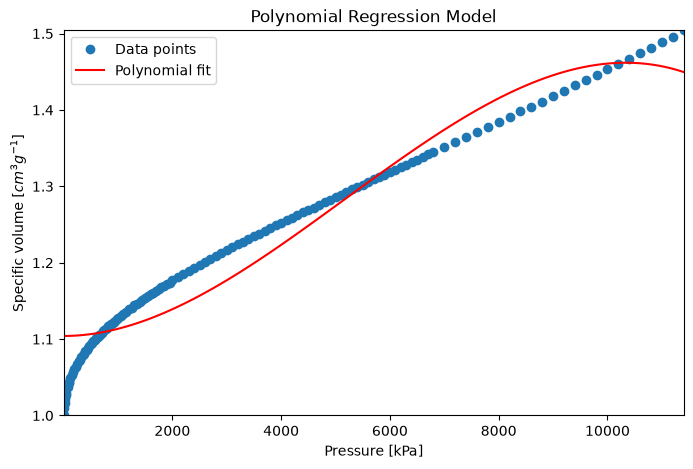

Degree: 4
The coefficients are: [[ 5.39086776e-20  3.36548772e-16  1.48348501e-12 -1.12705225e-16]]
The intercept is: [1.12604946]
The R-squared value is: 0.8657884836112323


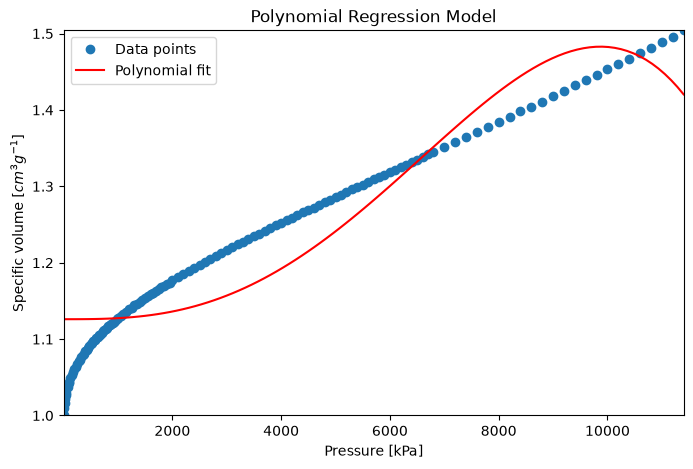

Degree: 5
The coefficients are: [[ 8.82717982e-28  6.55581003e-24  4.02726430e-20  1.86425643e-16
  -1.50131090e-20]]
The intercept is: [1.14153098]
The R-squared value is: 0.790503656078433


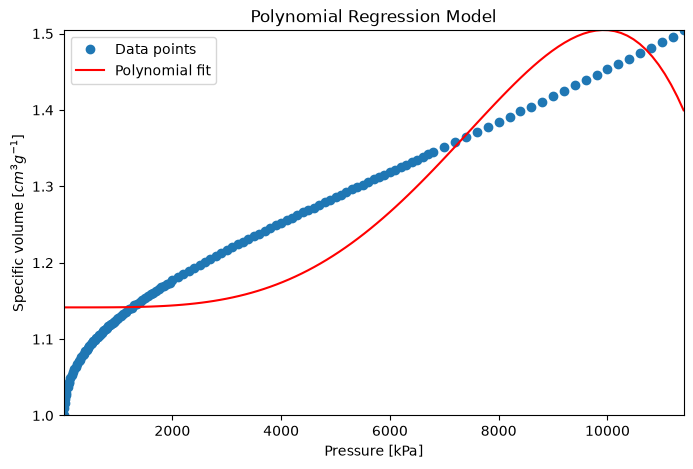

In [13]:
for i in [1,2,3,4,5]:
    model_poly = polynomial_model(Ps, Vs, i)
    print(f"Degree: {i}")
    print ("The coefficients are:", model_poly.named_steps['linear_regression'].coef_)      
    print ("The intercept is:", model_poly.named_steps['linear_regression'].intercept_)
    print ("The R-squared value is:", model_poly.score(Ps, Vs))
    plot_polynomial_fit(Ps, Vs, model_poly)

In [14]:
# Adding scaling to the pipeline to improve the model performance
from sklearn.preprocessing import StandardScaler

def polynomial_model_scaler(X, y,n):
    scaler = StandardScaler()
    pf = PolynomialFeatures(degree=n, include_bias=False)
    Lr = LinearRegression()
    model_poly = Pipeline([("scaler", scaler), ("polynomial_features", pf), ("linear_regression", Lr)])
    model_poly.fit(X, y)
    return model_poly



Degree: 1
The coefficients are: [[0.12685927]]
The intercept is: [1.21538235]
The R-squared value is: 0.9751457240928116


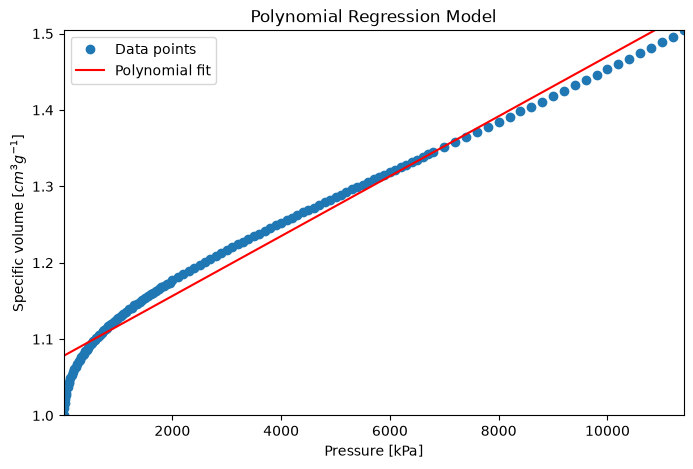

Degree: 2
The coefficients are: [[ 0.13933155 -0.0152107 ]]
The intercept is: [1.23059306]
The R-squared value is: 0.9870375378361614


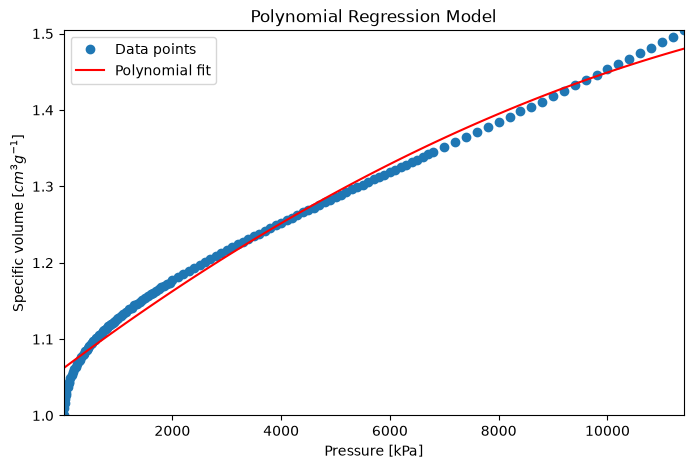

Degree: 3
The coefficients are: [[ 0.12270937 -0.03770818  0.01391312]]
The intercept is: [1.24168223]
The R-squared value is: 0.9944080310454866


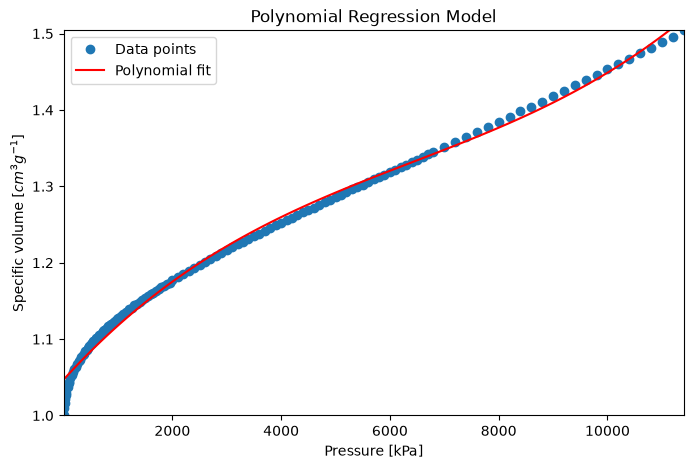

Degree: 4
The coefficients are: [[ 0.10341479 -0.02955979  0.03400558 -0.00893102]]
The intercept is: [1.2395702]
The R-squared value is: 0.9970238146790584


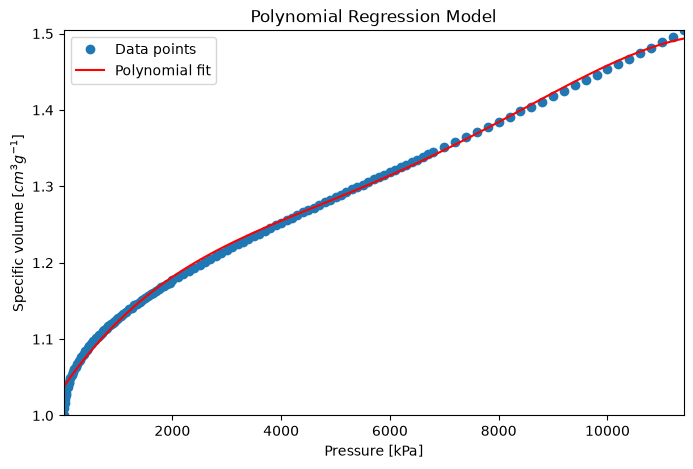

Degree: 5
The coefficients are: [[ 0.10154188 -0.00051854  0.0328054  -0.02939498  0.00691132]]
The intercept is: [1.23366335]
The R-squared value is: 0.9982622311353346


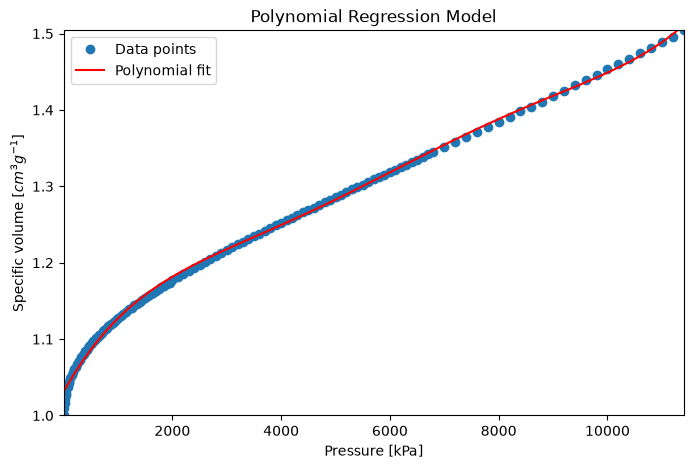

In [16]:
for i in range(1, 6):
    model_poly_scaler = polynomial_model_scaler(Ps, Vs, i)
    print(f"Degree: {i}")
    print ("The coefficients are:", model_poly_scaler.named_steps['linear_regression'].coef_)      
    print ("The intercept is:", model_poly_scaler.named_steps['linear_regression'].intercept_)
    print ("The R-squared value is:", model_poly_scaler.score(Ps, Vs))
    plot_polynomial_fit(Ps, Vs, model_poly_scaler)